In [3]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

In [5]:
def parse_clipboard_data(text):
    """
    Converts tabular text input (e.g. from copy-pasting) into x and y NumPy arrays.
    Assumes tab or space-separated two-column data.
    """
    # Split lines and filter out empty lines
    lines = [line.strip() for line in text.strip().splitlines() if line.strip()]
    # Split each line by whitespace or tab
    data = [list(map(float, line.split())) for line in lines]
    arr = np.array(data)
    x = arr[:, 0]
    y = arr[:, 1]
    return x, y

In [34]:
raw_data = """
0	21.0985
1	20.7581
2	21.4466
3	22.7656
4	26.0904
5	31.5952
6	41.8065
7	63.5435
8	85.2671
9	90.7693
10	78.2564
11	81.2270
12	99.1380
13	94.0381
14	66.2196
15	36.7633
16	25.7953
17	21.9763
18	20.6643
19	20.1656
"""

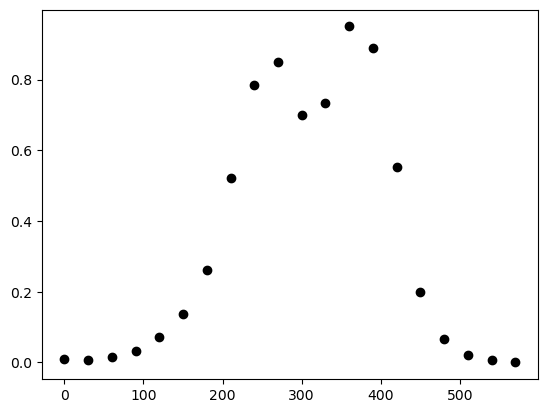

In [49]:
x,y = parse_clipboard_data(raw_data)

pxSize=30 # Pixel size in nm
x = x * pxSize  # Convert x to nm

y=(y-np.min(y))/(np.max(y)-np.min(y))  # Normalize y
y= y * 0.95

plt.figure()
plt.plot(x, y, 'ko')
plt.show()


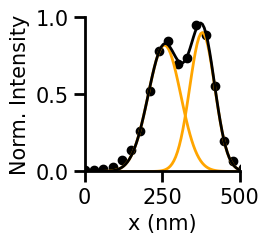

In [57]:


# params = [c1, mu1, sigma1, c2, mu2, sigma2]
x2 = np.linspace(min(x),max(x),100)

def single_gaussian(x,params):
    (c1, mu1, sigma1) = params
    res =   c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) 
    return res
def double_gaussian(x, params):
    (c1, mu1, sigma1, c2, mu2, sigma2) = params
    res =   c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) \
          + c2 * np.exp( - (x - mu2)**2.0 / (2.0 * sigma2**2.0) )
    return res

def single_gaussian_fit(params,x,y):
    fit = single_gaussian(x, params)
    return (fit - y)

def double_gaussian_fit(params, x, y):
    fit = double_gaussian(x, params)
    return (fit - y)


# Least squares fit. 
fit = leastsq(double_gaussian_fit, [0.9,250,100,1,350,100], args=(x, y))

# Extract parameters for the Gaussians
params1 = fit[0][:3]  # [c1, mu1, sigma1]
params2 = fit[0][3:]  # [c2, mu2, sigma2]

# Calculate FWHM for each Gaussian
fwhm1 = 2.355 * params1[2]
fwhm2 = 2.355 * params2[2]

fig = plt.figure(figsize=(2, 2))

# Plot data and fitted Gaussians
plt.plot(x, y, 'ko', markersize=6)
plt.plot(x2, single_gaussian(x2, params1), 'orange', linewidth=2)
plt.plot(x2, single_gaussian(x2, params2),'orange',linewidth=2)
plt.plot(x2, double_gaussian(x2,fit[0]), 'k',linewidth=2)

# Annotate FWHM on the plot
# plt.text(params1[1]-38, params1[0] / 2-0.1, f'{fwhm1:.0f}nm', color='b')
# plt.text(params2[1]-38, params2[0] / 2-0.1, f'{fwhm2:.0f}nm', color='g')


# Add double-sided arrows for FWHM
# plt.annotate('', xy=(params1[1] - fwhm1 / 2, params1[0] / 2), xytext=(params1[1] + fwhm1 / 2, params1[0] / 2),
#              arrowprops=dict(arrowstyle='<->', color='b'))
# plt.annotate('', xy=(params2[1] - fwhm2 / 2, params2[0] / 2), xytext=(params2[1] + fwhm2 / 2, params2[0] / 2),
#              arrowprops=dict(arrowstyle='<->', color='g'))

# Show plot

labels_fontSize=15
ticks_prms={"labelsize":15, "width":2,"length":8}

plt.xlabel('x (nm)',fontsize=labels_fontSize)
plt.ylabel('Norm. Intensity',fontsize=labels_fontSize)

plt.xlim(0, 500)
plt.ylim(0, 1)

plt.tick_params(axis='x',which='major',**ticks_prms)
plt.tick_params(axis='y',which='major',**ticks_prms)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(2)
plt.gca().spines['bottom'].set_linewidth(2)


plt.show()


fig.savefig("lineProfile_mitoFast_18h30roi.svg", format="svg", bbox_inches='tight')


In [39]:

print(params2[1]-params1[1])

121.94743647373991


In [ ]:
import csv
import matplotlib.pyplot as plt
import numpy as np
# Specify the path to your CSV file
csv_file_path = r'C:\Users\guillaume.minet\Documents\ValuesHDN.csv'
pxSize = 30
x = []
y = []

# Read data from the CSV file
with open(csv_file_path, 'r') as file:
    reader = csv.reader(file, delimiter=',')  # Use '\t' as the delimiter for tab-separated ys
    next(reader)  # Skip the first row (titles)
    for row in reader:
        # Assuming each row has two columns: index and y
        x.append(int(row[0]))
        y.append(float(row[1]))
x=np.stack(x) * pxSize
y=np.stack(y)
y = y - np.min(y)

plt.figure()
plt.plot(x,y)

In [ ]:
x2 = np.linspace(min(x),max(x),100)

# Least squares fit. 
fit = leastsq(single_gaussian_fit, [1.3,250,50], args=(x, y))

# Extract parameters for the Gaussians
params1 = fit[0]

# Calculate FWHM for each Gaussian
fwhm1 = 2.355 * params1[2]

# Plot data and fitted Gaussians
plt.plot(x, y, 'r--')
plt.plot(x2, single_gaussian(x2, params1), c='b')

# Annotate FWHM on the plot
plt.text(params1[1]-30, params1[0] / 2-0.1, f'{fwhm1:.0f}nm', color='b')

# Add double-sided arrows for FWHM
plt.annotate('', xy=(params1[1] - fwhm1 / 2, params1[0] / 2), xytext=(params1[1] + fwhm1 / 2, params1[0] / 2),
             arrowprops=dict(arrowstyle='<->', color='b'))

# Show plot
plt.xlabel('x')
plt.ylabel('Intensity')
plt.title('Double Gaussian Fit with FWHM')
plt.show()
